swra echo-3
→ DiFuMo
→ ROI time series
→ events.tsv split
→ Belief FC
→ Photo FC
→ Belief - Photo

##Load sub1's tomloc2 run-04 echo3

In [1]:
import nibabel as nib
fmri_filepath = '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/NTUSEC008/nii/ses01/REST_SES01/arREST_REST_3.4x3.4x4_20220304142158_7.nii'


In [2]:
fmri_img = nib.load(fmri_filepath)
print(fmri_img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (64, 64, 36, 260)
affine:
[[-3.43447447e+00  8.38689804e-02 -1.36490822e-01  1.06014336e+02]
 [ 9.84002352e-02  3.40715241e+00 -5.17832518e-01 -8.62018051e+01]
 [-1.05403662e-01  4.47978377e-01  3.96399021e+00 -9.43488388e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  64  64  36 260   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.         3.4375002  3.4375     3.9999998  2.         0.
  0.         0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10

##Using DiFuMo64 atlas

In [3]:
from nilearn import datasets
# atlas_dataset = datasets.fetch_atlas_difumo(data_dir="/home/chsinchi/Hsin-Chi_Project/3814", dimension=64)
# atlas_dataset = datasets.fetch_atlas_aal(data_dir="/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/AAL_ATLAS",version='SPM12')

import os
from nilearn.maskers import NiftiLabelsMasker

# 1. 定義您的資料夾路徑
atlas_dir = "/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/AAL_ATLAS/AAL3"

# 2. 指定 NIfTI 影像檔的完整路徑 (請依據您資料夾內的實際檔名微調)
aal_maps_path = os.path.join(atlas_dir, "AAL3v1.nii")

# 3. 解析標籤檔 (txt) 並建立 labels 列表
aal_labels_path = os.path.join(atlas_dir, "AAL3v1.nii.txt")
labels = []

# 手動讀取 txt 檔中的腦區名稱
# AAL 的 txt 檔通常每行的格式為: "區域編號 區域名稱" (例如: 1 Precentral_L)
with open(aal_labels_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            # 取第二個部分作為腦區名稱
            roi_name = parts[1]
            labels.append(roi_name)

# 4. 將它包裝成如同 nilearn 回傳的 aal_dataset 結構
atlas_dataset = {
    'maps': aal_maps_path,
    'labels': labels
}

# 檢查是否正確載入
print("AAL3 影像路徑:", atlas_dataset['maps'])
print(f"成功讀取 {len(atlas_dataset['labels'])} 個腦區標籤。")
print("標籤範例 (前5個):", atlas_dataset['labels'][:5])




# atlas_filepath = atlas_dataset['maps']
# labels = atlas_dataset['labels']

AAL3 影像路徑: /bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/AAL_ATLAS/AAL3/AAL3v1.nii
成功讀取 170 個腦區標籤。
標籤範例 (前5個): ['Precentral_L', 'Precentral_R', 'Frontal_Sup_2_L', 'Frontal_Sup_2_R', 'Frontal_Mid_2_L']


In [4]:
from nilearn import datasets


from nilearn import image

# 直接指定您剛剛解壓縮出來的 AAL3v2 影像檔路徑
# 檔名可能會依據解壓縮結果有些微不同，請確認實際的 .nii 或 .nii.gz 檔名
atlas_filepath = "/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/AAL_ATLAS/aal_SPM12/AAL3v1.nii"

# 直接載入圖譜
atlas_dataset_img = image.load_img(atlas_filepath)

print("成功載入圖譜的形狀:", atlas_dataset_img.shape)

# 下載 AAL 圖譜並指定存放路徑
# atlas_dataset = datasets.fetch_atlas_aal ( version = 'SPM12' , data_dir = '/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/AAL_ATLAS' , url = None , resume = True , verbose = 1 )



成功載入圖譜的形狀: (91, 109, 91)


In [5]:
import os

# 1. 設定 maps (直接使用您的路徑變數)
maps = atlas_filepath

# 2. 設定 labels
# 請將這裡的 .txt 檔名替換為您解壓縮出來的實際標籤檔名
label_path = "/bml/projects/07_inference-clinical-trial/projects/07-09_ntsec-lego-fmri-connectivity/data/derivatives/AAL_ATLAS/aal_SPM12/AAL3v1.nii.txt"

labels = ["Background"] # 預設 index 0 為背景

# 讀取標籤檔
try:
    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                # AAL 的 txt 檔通常格式為："縮寫 數字代碼 索引" 或類似格式
                # 這裡假設腦區名稱在第一或第二個欄位，請根據您的 txt 檔實際內容調整 index (例如 parts[0] 或 parts[1])
                # 以 AAL3 為例，通常腦區名稱字串是不帶空白的
                
                # 這裡抓取長度大於 2 的字串作為標籤名，避開純數字
                region_name = next((p for p in parts if not p.isdigit()), "Unknown")
                labels.append(region_name)
                
    print("成功載入標籤，前 5 個為:")
    print(labels[:5])
    print(f"總共載入 {len(labels)} 個標籤 (包含背景)")

except FileNotFoundError:
    print(f"找不到標籤檔：{label_path}，請檢查路徑與檔名是否正確！")

# 3. (選擇性) 將它們打包成像 nilearn 回傳的物件格式
# 這樣您後續的程式碼就不需要大改
class CustomAtlas:
    pass

atlas_dataset = CustomAtlas()
atlas_dataset.maps = maps
atlas_dataset.labels = labels

# 測試呼叫
# print(atlas_dataset.maps)
# print(atlas_dataset.labels)

成功載入標籤，前 5 個為:
['Background', 'Precentral_L', 'Precentral_R', 'Frontal_Sup_2_L', 'Frontal_Sup_2_R']
總共載入 171 個標籤 (包含背景)


In [6]:
# 1. 更改 Import：引入 NiftiLabelsMasker
from nilearn.maskers import NiftiLabelsMasker
import matplotlib.pyplot as plt

# 2. 初始化正確的 Masker
atlas_masker = NiftiLabelsMasker(
    labels_img=atlas_filepath,    # ★ 注意：參數名稱從 maps_img 變成了 labels_img
    standardize='zscore_sample', 
    memory='nilearn_cache', 
    memory_level=1
)

# 3. 提取時間序列
time_series = atlas_masker.fit_transform(fmri_filepath)

# 4. 再次檢查維度
print(time_series.shape)

(260, 164)


/tmp/ipykernel_3919790/2370176195.py:14: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(133), np.uint8(134)}. Label image only contains 165 labels (including background).
  time_series = atlas_masker.fit_transform(fmri_filepath)


In [7]:
import numpy as np

TR = 2

def extract_condition_ts(time_series, events, condition, tr):
    chunks = []

    condition_events = events[events["trial_type"] == condition]

    for _, row in condition_events.iterrows():
        start = int(row["onset"] / tr)
        end = int((row["onset"] + row["duration"]) / tr)
        chunks.append(time_series[start:end, :])

    return np.vstack(chunks)

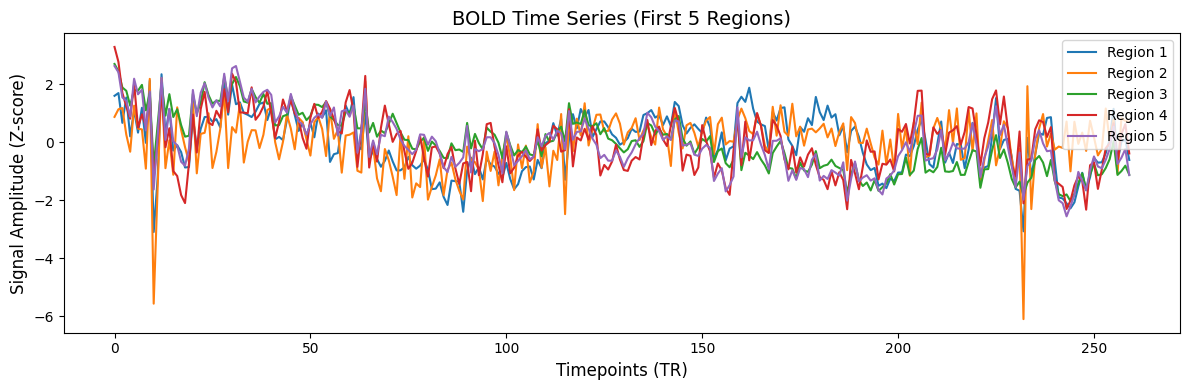

In [8]:
import matplotlib.pyplot as plt

# 設定畫布大小
plt.figure(figsize=(12, 4))

plt.plot(time_series[:, 0:5])

# 添加標籤
plt.title("BOLD Time Series (First 5 Regions)", fontsize=14)
plt.xlabel("Timepoints (TR)", fontsize=12)
plt.ylabel("Signal Amplitude (Z-score)", fontsize=12)

# 顯示圖例 (可選，如果是 DiFuMo 可以帶入標籤名稱)
plt.legend([f"Region {i+1}" for i in range(5)], loc='upper right')

plt.tight_layout()
plt.show()

In [12]:
from nilearn.connectome import ConnectivityMeasure
import numpy as np

TR = 2
correlation_measure = ConnectivityMeasure(kind='correlation')

photo_fc = correlation_measure.fit_transform([time_series])[0]

np.fill_diagonal(photo_fc, 0)


/tmp/ipykernel_3919790/2195834841.py:7: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  photo_fc = correlation_measure.fit_transform([time_series])[0]


In [14]:
import numpy as np

# 1. 確認維度 (應該要是 腦區數 x 腦區數，例如 64 x 64)
print(f"矩陣維度: {photo_fc.shape}")

# 2. 檢查是否有 NaN 壞死數據
nan_count = np.isnan(photo_fc).sum()
print(f"矩陣中的 NaN 數量: {nan_count}")

# 3. 檢查數值範圍 (對角線歸零後，合理範圍通常在 -1 到 1 之間)
# 使用 np.nanmax 避免因為有 NaN 而報錯
if nan_count == 0:
    print(f"最大相關係數: {np.max(photo_fc):.3f}")
    print(f"最小相關係數: {np.min(photo_fc):.3f}")
    

矩陣維度: (164, 164)
矩陣中的 NaN 數量: 0
最大相關係數: 0.906
最小相關係數: -0.738


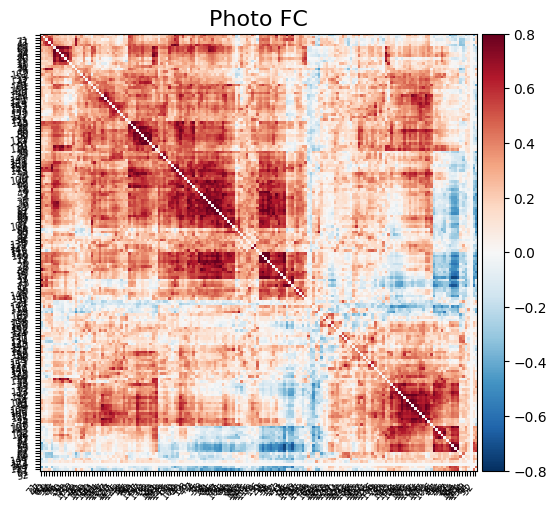

In [ ]:
from nilearn import plotting

plotting.plot_matrix(
    photo_fc,
    labels=range(1, time_series.shape[-1] + 1),
    vmax=0.8,
    vmin=-0.8,
    reorder='complete',
    auto_fit=True,
    title="Photo FC"
)

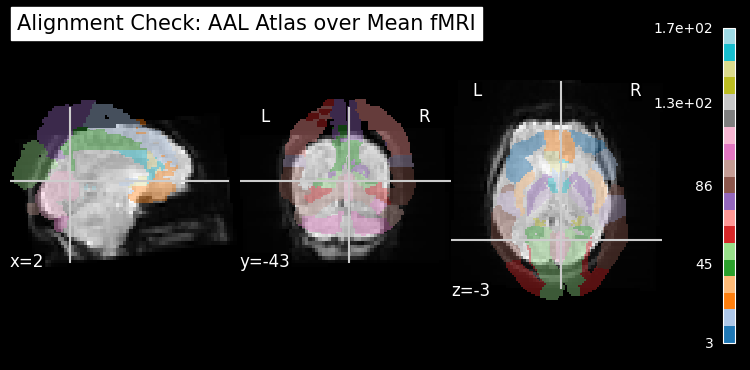

In [21]:
from nilearn.image import mean_img
from nilearn import plotting

# 1. 將 4D fMRI 影像沿著時間軸平均，轉換為一張清晰的 3D 影像
mean_fmri = mean_img(fmri_img)

# 2. 視覺化疊圖檢查 (使用平均後的 3D 影像作為背景)
plotting.plot_roi(
    roi_img=atlas_dataset_img,  # AAL 3D 圖譜
    bg_img=mean_fmri,           # 降維後的 3D fMRI 背景
    alpha=0.4,                  
    cmap='tab20',               
    title="Alignment Check: AAL Atlas over Mean fMRI",
    dim=-0.5,                   
    draw_cross=True             
)

plotting.show()